# 7.13 Changing Parameters Using the API

In HNN-Core, a model is a single Python object: a `Network`. Nearly every parameter of
your model itself, from the length of a dendrite to the timing of an input, is stored on that
object as an ordinary attribute or dictionary entry that you can read and change. The
few that are not are arguments to the functions that create the network or run the
simulation.

This page goes through every group of parameters, showing where each one lives and how
to change it.

| Parameters | Where they live | Section |
| --- | --- | --- |
| Number of cells, and their spacing | `neymotin_2020_model(mesh_shape=...)`, `net.update_cell_positions()` | 1. Creating the Network |
| Temperature and spike threshold | `net._params`, `net.threshold`, and each connection | 2. Simulation-wide Settings |
| Cell geometry, synapse kinetics, ion channels | `net.cell_types[<cell type>]["cell_object"]` | 3. Cell Properties |
| Weight, delay and spatial spread of every connection | `net.connectivity`, searched with `pick_connection()` | 4. Recurrent Connections |
| Drive timing and random seeds | `net.external_drives[<drive name>]` | 5. External Drives |
| Tonic input currents | `net.external_biases[<bias name>]` | 6. Tonic Inputs |
| Simulation length, time step, trials, recordings | arguments to `simulate_dipole()` | 7. Running the Simulation |
| Dipole smoothing and scaling | methods of the simulated `Dipole` | 8. Processing the Dipole |

Every change below is made in-place on the same network, which we simulate in Section 7
and save to disk in Section 9. The values we choose are only there to show *how* to
change each parameter; they are not a recommended model.

## 0. Preamble

Let's import what we need, followed by creating a helper function that we will use only for illustration purposes:

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from hnn_core import (
    neymotin_2020_model,
    pick_connection,
    read_network_configuration,
    simulate_dipole,
)
from hnn_core.viz import plot_cell_connectivity, plot_connectivity_matrix

--No graphics will be displayed.


`show()` is the only helper function on this page. It evaluates each expression you pass
it and prints the expression next to its current value, so that each example reads as
"here is where the parameter lives, and here is what it holds right now".

In [2]:
def show(*exprs):
    """Evaluate expressions in the notebook namespace and print them."""
    width = max(len(expr) for expr in exprs)
    for expr in exprs:
        print(f"{expr:<{width}}  ->  {eval(expr, globals())}")

## 1. Creating the network

`neymotin_2020_model()` creates HNN-Core's default network: layers 2/3 and 5 each hold a
10 × 10 square grid of pyramidal cells with interspersed basket cells, plus all of the local
connections between them; see our [Getting Started pages for details on the model itself](https://jonescompneurolab.github.io/textbook/content/01_getting_started/template_model.html). It starts with no drives; we add those in Section 5.

The size of the pyramidal cell square grid is set by `mesh_shape`, and can only be chosen when
the network is created. Every cell is given an ID (its "GID") based on the size of the
grid, and every connection is defined in terms of those IDs, so a network with a
different number of cells has to be created from scratch. Note that a different `mesh_shape` produces a network containing a different number of cells!

In [3]:
net = neymotin_2020_model()
print(net)

# A 5 x 5 grid is a separate network, created from scratch:
print(neymotin_2020_model(mesh_shape=(5, 5)))  # default is (10, 10)

<Network | 35 L2_basket cells
100 L2_pyramidal cells
35 L5_basket cells
100 L5_pyramidal cells>
<Network | 10 L2_basket cells
25 L2_pyramidal cells
10 L5_basket cells
25 L5_pyramidal cells>


What you *can* change afterwards is the spacing of the grid. `update_cell_positions()`
takes `inplane_distance`, the distance between neighboring pyramidal cell somas, and
`layer_separation`, the vertical distance between the layer 2/3 and layer 5 somas (both
in µm). Cell positions do not affect the simulated dipole, but they do matter for
extracellular recordings and for plots of the network. These have been tuned for the default network, and it is strongly recommended that you do *not* change these values unless you know what you're doing.

In [4]:
print("---------------\nInitial values:\n---------------")
show("net.pos_dict['L5_pyramidal'][1]", "net.pos_dict['L2_pyramidal'][1]")

net.update_cell_positions(inplane_distance=2.0, layer_separation=1500.0)

print("---------------\n After change:\n---------------")
show("net.pos_dict['L5_pyramidal'][1]", "net.pos_dict['L2_pyramidal'][1]")

---------------
Initial values:
---------------
net.pos_dict['L5_pyramidal'][1]  ->  (0.0, 1.0, 0)
net.pos_dict['L2_pyramidal'][1]  ->  (0.0, 1.0, 1307.4)
---------------
 After change:
---------------
net.pos_dict['L5_pyramidal'][1]  ->  (0.0, 2.0, 0.0)
net.pos_dict['L2_pyramidal'][1]  ->  (0.0, 2.0, 1500.0)


If you are interested in starting with the default ERP simulation, then you can conveniently add the standard ERP drives by passing `add_drives_from_params=True` to the network creation function, such as below. However, for the rest of this notebook, we will be starting from a network with no drives for illustrative purposes.

In [5]:
net_default_drives = neymotin_2020_model(add_drives_from_params=True)
net_default_drives.external_drives

{'evdist1': <External drive 'evdist1'
 drive class: evoked
 target location: distal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_pyramidal']
 number of drive cells: 235
 cell-specific: True
 dynamic parameters:
 	mu: 63.53
 	sigma: 3.85
 	numspikes: 1>,
 'evprox1': <External drive 'evprox1'
 drive class: evoked
 target location: proximal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 270
 cell-specific: True
 dynamic parameters:
 	mu: 26.61
 	sigma: 2.47
 	numspikes: 1>,
 'evprox2': <External drive 'evprox2'
 drive class: evoked
 target location: proximal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 270
 cell-specific: True
 dynamic parameters:
 	mu: 137.12
 	sigma: 8.33
 	numspikes: 1>}

## 2. Simulation-wide settings

AES TODO

The temperature and the spike threshold apply to the whole network. There is no public setter for them yet, so
you change them in `net._params`, the network's private dictionary of build settings.
It holds other entries as well, but these two are the only ones you need to set there;
every other parameter is covered by the attributes and arguments on this page.

- `celsius` is the temperature (°C) at which NEURON runs the ion channel kinetics. Default is 37°C.
- `threshold` is the membrane potential (mV) that a cell's soma must cross for a spike to
  be counted and sent on to its targets. It is stored in three places, which should
  always agree:
    - `net._params["threshold"]`, used to detect spikes in every cell;
    - `net.connectivity[idx]["nc_dict"]["threshold"]`, a copy on every existing
      connection;
    - `net.threshold`, the value copied into every connection created later.

thresholds only affect source cells

In [6]:
print("---------------\nInitial values:\n---------------")
show("net._params['celsius']", "net._params['threshold']", "net.threshold")

net._params["celsius"] = 36.0

new_threshold = -10.0
net._params["threshold"] = new_threshold
net.threshold = new_threshold  # connections created from now on, including drives
for conn in net.connectivity:  # connections that already exist
    conn["nc_dict"]["threshold"] = new_threshold

print("---------------\n After change:\n---------------")
show("net._params['celsius']", "net._params['threshold']", "net.threshold")

---------------
Initial values:
---------------
net._params['celsius']    ->  37.0
net._params['threshold']  ->  0.0
net.threshold             ->  0.0
---------------
 After change:
---------------
net._params['celsius']    ->  36.0
net._params['threshold']  ->  -10.0
net.threshold             ->  -10.0


## 3. Cell properties

Every cell of a given type is built from that type's *template*, a [`Cell` object](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Cell.html#hnn_core.Cell) stored
at `net.cell_types[<cell type>]["cell_object"]`. Change the template, and every cell of
that type changes with it. The default network has four cell types: `L2_basket`,
`L2_pyramidal`, `L5_basket` and `L5_pyramidal`.

A template is made of *Sections*, which are the soma and the individual pieces of
dendrite. Its parameters come in three groups: 

1. the geometry and passive properties of each section, 
2. the ion channels in each section, and
3. the kinetics of the synapses on the cell.

Note that these are not converted into proper [NEURON Section objects](https://www.neuronsimulator.org/en/9.0.2/progref/modelspec/programmatic/topology/geometry.html) until simulation time.

In [7]:
l2_pyr = net.cell_types["L2_pyramidal"]["cell_object"]
l5_pyr = net.cell_types["L5_pyramidal"]["cell_object"]
l2_basket = net.cell_types["L2_basket"]["cell_object"]

print("L2_pyramidal sections:", list(l2_pyr.sections))
print("L5_pyramidal sections:", list(l5_pyr.sections))
print("L2_basket sections:   ", list(l2_basket.sections))

L2_pyramidal sections: ['apical_trunk', 'apical_1', 'apical_tuft', 'apical_oblique', 'basal_1', 'basal_2', 'basal_3', 'soma']
L5_pyramidal sections: ['apical_trunk', 'apical_1', 'apical_2', 'apical_tuft', 'apical_oblique', 'basal_1', 'basal_2', 'basal_3', 'soma']
L2_basket sections:    ['soma']


### Geometry and passive properties

Each Section has five of these:

| Property | Meaning | Units |
| --- | --- | --- |
| `L` | length | µm |
| `diam` | diameter | µm |
| `cm` | membrane capacitance | µF/cm² |
| `Ra` | axial resistivity | Ω·cm |
| `v0` | membrane potential at the start of the simulation | mV |

They are read-only attributes, because changing a length also has to move the 3-D end
points of the section and of everything attached to it. Change them with
[`Cell.modify_section()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Cell.html#hnn_core.Cell.modify_section), which does both. It is strongly recommended that you do *not* change `L` or `diam` unless you know what you are doing, in part because you will need to adjust `nseg`, the number of segments NEURON divides a section into, manually.

In [8]:
print("---------------\nInitial values:\n---------------")
show("l5_pyr.sections['soma']", "l5_pyr.sections['apical_tuft']")

l5_pyr.modify_section("soma", L=40.0, diam=30.0)
l5_pyr.modify_section("apical_tuft", cm=0.9, Ra=180.0, v0=-68.0)

print("---------------\n After change:\n---------------")
show("l5_pyr.sections['soma']", "l5_pyr.sections['apical_tuft']")

---------------
Initial values:
---------------
l5_pyr.sections['soma']         ->  L=39.0, diam=28.9, cm=0.85, Ra=200.0, v0=-72.0
l5_pyr.sections['apical_tuft']  ->  L=425.0, diam=3.4, cm=0.85, Ra=200.0, v0=-67.3
---------------
 After change:
---------------
l5_pyr.sections['soma']         ->  L=40.0, diam=30.0, cm=0.85, Ra=200.0, v0=-72.0
l5_pyr.sections['apical_tuft']  ->  L=425.0, diam=3.4, cm=0.9, Ra=180.0, v0=-68.0


### Ion channels

Each Section's `.mechs` holds the NEURON mechanisms (ion channels) inserted in that
section, each with its own parameters: `sections[<section>].mechs[<mechanism>][<parameter>]`.
The default cells use these:

| Mechanism | Ion Channel | Parameters (units) | Cell types |
| --- | --- | --- | --- |
| `hh2` | Hodgkin–Huxley sodium, potassium and leak | `gnabar_hh2`, `gkbar_hh2`, `gl_hh2` (S/cm²); `el_hh2` (mV) | all |
| `km` | slow (M-type) potassium | `gbar_km` (pS/µm²) | pyramidal |
| `ca` | high-threshold calcium | `gbar_ca` (pS/µm²) | L5 pyramidal |
| `cad` | calcium decay dynamics (not an ion channel) | `taur_cad` (ms) | L5 pyramidal |
| `kca` | calcium-activated potassium | `gbar_kca` (pS/µm²) | L5 pyramidal |
| `cat` | low-threshold (T-type) calcium | `gbar_cat` (S/cm²) | L5 pyramidal |
| `ar` | anomalous rectifier (h-current) | `gbar_ar` (S/cm²) | L5 pyramidal |

Each section has its own copy of these values, so a value that should be the same in all
dendrites is set with a loop over sections. Basket cells start with an empty `hh2`
dictionary, meaning the built-in values are used until you add your own.

In [9]:
show("l5_pyr.sections['soma'].mechs", "l2_basket.sections['soma'].mechs")
print("---------------\nInitial values:\n---------------")
show(
    "l5_pyr.sections['soma'].mechs['hh2']",
    "l2_basket.sections['soma'].mechs",
    "l5_pyr.sections['apical_1'].mechs['km']",
)
# One section at a time...
l5_pyr.sections["soma"].mechs["hh2"]["gnabar_hh2"] = 0.17
l2_basket.sections["soma"].mechs["hh2"]["gkbar_hh2"] = 0.04

# ...or the same value in every dendritic section
for sec_name, section in l5_pyr.sections.items():
    if sec_name != "soma":
        section.mechs["km"]["gbar_km"] = 220.0

print("---------------\n After change:\n---------------")
show(
    "l5_pyr.sections['soma'].mechs['hh2']",
    "l2_basket.sections['soma'].mechs",
    "l5_pyr.sections['apical_1'].mechs['km']",
)

l5_pyr.sections['soma'].mechs     ->  {'hh2': {'gkbar_hh2': 0.01, 'gnabar_hh2': 0.16, 'gl_hh2': 4.26e-05, 'el_hh2': -65.0}, 'ca': {'gbar_ca': 60.0}, 'cad': {'taur_cad': 20.0}, 'kca': {'gbar_kca': 0.0002}, 'km': {'gbar_km': 200.0}, 'cat': {'gbar_cat': 0.0002}, 'ar': {'gbar_ar': 1e-06}}
l2_basket.sections['soma'].mechs  ->  {'hh2': {}}
---------------
Initial values:
---------------
l5_pyr.sections['soma'].mechs['hh2']     ->  {'gkbar_hh2': 0.01, 'gnabar_hh2': 0.16, 'gl_hh2': 4.26e-05, 'el_hh2': -65.0}
l2_basket.sections['soma'].mechs         ->  {'hh2': {}}
l5_pyr.sections['apical_1'].mechs['km']  ->  {'gbar_km': 200.0}
---------------
 After change:
---------------
l5_pyr.sections['soma'].mechs['hh2']     ->  {'gkbar_hh2': 0.01, 'gnabar_hh2': 0.17, 'gl_hh2': 4.26e-05, 'el_hh2': -65.0}
l2_basket.sections['soma'].mechs         ->  {'hh2': {'gkbar_hh2': 0.04}}
l5_pyr.sections['apical_1'].mechs['km']  ->  {'gbar_km': 220.0}


### Conductances that vary with distance

TODO DISCUSS do we want to expose how to do this? I think so

A mechanism parameter can also be a function of distance from the soma. In the default
L5 pyramidal cell, `gbar_ar` increases exponentially along every dendritic section. When
the template is created, each such function is evaluated at the center of every segment
and replaced by a pair of lists, `[segment positions, values]`:

In [10]:
print("---------------\nInitial values:\n---------------")
positions, values = l5_pyr.sections["apical_1"].mechs["ar"]["gbar_ar"]
print(f"apical_1 gbar_ar: {len(values)} segments, {values[0]:.2e} to {values[-1]:.2e}")

---------------
Initial values:
---------------
apical_1 gbar_ar: 13 segments, 1.65e-06 to 1.09e-05


To change a parameter like this, you can either assign a single number, which makes it
uniform across the section, or assign a new function of distance (in µm) and then call
`Cell._compute_section_mechs()` to evaluate it on every segment. That method is private, but
for now it is the only way to do this. Do the same after changing the length of any
section, because the stored values were computed for the old geometry and are not
updated automatically.

In [11]:
# Double the h-current density in every dendritic section, keeping its shape
for sec_name, section in l5_pyr.sections.items():
    if sec_name != "soma":
        section.mechs["ar"]["gbar_ar"] = lambda x: 2e-6 * np.exp(3e-3 * x)
l5_pyr._compute_section_mechs()

print("---------------\n After change:\n---------------")
positions, values = l5_pyr.sections["apical_1"].mechs["ar"]["gbar_ar"]
print(f"apical_1 gbar_ar: {len(values)} segments, {values[0]:.2e} to {values[-1]:.2e}")

---------------
 After change:
---------------
apical_1 gbar_ar: 13 segments, 3.31e-06 to 2.18e-05


### Synapse kinetics

A `Cell` template's `.synapses` has one entry per receptor type: `ampa`, `nmda`, `gabaa` and
`gabab` (basket cells have no `gabab`). Each has parameters for a reversal potential `e` (mV) and a rise
and decay time constant, `tau1` and `tau2` (ms), unless you are using a custom NEURON synapse model that you have provided and which may use different parameters. The remaining entry, `mechname`, names
the NEURON synapse model that uses them, and can be ignored unless you are using a custom NEURON synapse model that you have provided.

These describe the synapses *onto* a cell type (not from), so they apply to every connection that
targets it, whether from other cells or from drives. The example below slows GABA-B
inhibition onto both pyramidal cell types, which is one of the changes that
`law_2021_model()` makes to the default network.

In [12]:
print("---------------\nInitial values:\n---------------")
show("l5_pyr.synapses['gabab']")

for cell_type in ("L2_pyramidal", "L5_pyramidal"):
    synapses = net.cell_types[cell_type]["cell_object"].synapses
    synapses["gabab"]["tau1"] = 45.0
    synapses["gabab"]["tau2"] = 200.0

print("---------------\n After change:\n---------------")
show("l2_pyr.synapses['gabab']", "l5_pyr.synapses['gabab']")

---------------
Initial values:
---------------
l5_pyr.synapses['gabab']  ->  {'e': -80.0, 'tau1': 1.0, 'tau2': 20.0, 'mechname': 'Exp2Syn'}
---------------
 After change:
---------------
l2_pyr.synapses['gabab']  ->  {'e': -80.0, 'tau1': 45.0, 'tau2': 200.0, 'mechname': 'Exp2Syn'}
l5_pyr.synapses['gabab']  ->  {'e': -80.0, 'tau1': 45.0, 'tau2': 200.0, 'mechname': 'Exp2Syn'}


## 4. Recurrent Connections

Every connection in the network is an entry in the list `net.connectivity`. Each entry
connects one cell type (or drive, discussed later in Section 5) to another, at one location on the
target cells (`"proximal"`, `"distal"` or `"soma"`), through one receptor type. The
default network comes with 16 connections between its own cells, which together reflect
the canonical neocortical microcircuit.

A connection's parameters fall into two groups:

- **Parameters you can change at any time** set how strong and how fast a connection is:
  its weight, delay, space constant, gain and threshold.
- **Parameters fixed when a connection is created** decide *which pairs of cells* it
  connects: its source and target cells, location, receptor, and connection
  probability. Changing these means deleting the connection and adding it again.

A connection's position in `net.connectivity` depends on the order in which connections
were created, so you should never alter the indices of this list yourself, or hard-code your code around them. **Instead, find
connections with
[`pick_connection()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.pick_connection.html#hnn_core.pick_connection)**,
which takes any combination of `src_gids`, `target_gids`, `loc` and `receptor` and returns
the index of every connection that matches. You can pass cell type names as `src_gids`
and `target_gids`, and a drive's name as `src_gids`. Once you have found the appropriate
connection indices, it is recommended to use loops to then update the parameter in
question.

### Parameters you can change at any time

These are stored in each connection's `nc_dict`, and read when the network is built for a
simulation, so you can change them in place:

| Key | Meaning |
| --- | --- |
| `A_weight` | peak synaptic conductance (µS) between two cells at the same horizontal position |
| `A_delay` | synaptic delay (ms) between two cells at the same horizontal position |
| `lamtha` | space constant: how quickly the weight falls off, and the delay grows, with the horizontal distance between two cells (in units of the in-plane distance between cells) |
| `gain` | multiplier applied to `A_weight` when the network is built |
| `threshold` | spike threshold (see Section 2) |

In [13]:
print("---------------\nInitial values:\n---------------")
for idx, conn in enumerate(net.connectivity):
    print(
        f"{idx:>2}  {conn['src_type']:>12} -> {conn['target_type']:<12}  "
        f"{conn['loc']:<8}  {conn['receptor']:<5}  {conn['nc_dict']}"
    )

---------------
Initial values:
---------------
 0  L2_pyramidal -> L2_pyramidal  proximal  nmda   {'A_delay': 1.0, 'A_weight': 0.0005, 'lamtha': 3.0, 'threshold': -10.0, 'gain': 1.0}
 1  L2_pyramidal -> L2_pyramidal  proximal  ampa   {'A_delay': 1.0, 'A_weight': 0.0005, 'lamtha': 3.0, 'threshold': -10.0, 'gain': 1.0}
 2  L5_pyramidal -> L5_pyramidal  proximal  nmda   {'A_delay': 1.0, 'A_weight': 0.0005, 'lamtha': 3.0, 'threshold': -10.0, 'gain': 1.0}
 3  L5_pyramidal -> L5_pyramidal  proximal  ampa   {'A_delay': 1.0, 'A_weight': 0.0005, 'lamtha': 3.0, 'threshold': -10.0, 'gain': 1.0}
 4     L2_basket -> L2_pyramidal  soma      gabaa  {'A_delay': 1.0, 'A_weight': 0.05, 'lamtha': 50.0, 'threshold': -10.0, 'gain': 1.0}
 5     L2_basket -> L2_pyramidal  soma      gabab  {'A_delay': 1.0, 'A_weight': 0.05, 'lamtha': 50.0, 'threshold': -10.0, 'gain': 1.0}
 6     L5_basket -> L5_pyramidal  soma      gabaa  {'A_delay': 1.0, 'A_weight': 0.025, 'lamtha': 70.0, 'threshold': -10.0, 'gain': 1.0}
 7

In [14]:
# Weaken recurrent NMDA excitation between L5 pyramidal cells
indices = pick_connection(
    net, src_gids="L5_pyramidal", target_gids="L5_pyramidal", receptor="nmda"
)
for idx in indices:
    net.connectivity[idx]["nc_dict"]["A_weight"] = 0.0004

# Leave arguments out to match more connections. L2 pyramidal cells connect to L5
# pyramidal cells at both proximal and distal locations, so this finds both.
indices = pick_connection(net, src_gids="L2_pyramidal", target_gids="L5_pyramidal")
for idx in indices:
    net.connectivity[idx]["nc_dict"]["A_delay"] = 1.5
    net.connectivity[idx]["nc_dict"]["lamtha"] = 4.0

print("---------------\n After change:\n---------------")
print("L2_pyramidal -> L5_pyramidal connections:", indices)
show("net.connectivity[indices[0]]['nc_dict']", "net.connectivity[indices[1]]['nc_dict']")

---------------
 After change:
---------------
L2_pyramidal -> L5_pyramidal connections: [8, 9]
net.connectivity[indices[0]]['nc_dict']  ->  {'A_delay': 1.5, 'A_weight': 0.00025, 'lamtha': 4.0, 'threshold': -10.0, 'gain': 1.0}
net.connectivity[indices[1]]['nc_dict']  ->  {'A_delay': 1.5, 'A_weight': 0.00025, 'lamtha': 4.0, 'threshold': -10.0, 'gain': 1.0}


[`plot_cell_connectivity()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.viz.plot_cell_connectivity.html#hnn_core.viz.plot_cell_connectivity)
shows what these parameters mean in space. For one connection, the left panel shows the
positions of the source cells, and the right panel marks one of them (large red square)
and colors each target cell by the weight it receives from that source cell. The weight is
largest at the source cell's horizontal position and falls off with distance, at a rate
set by `lamtha`. Below, we plot the proximal L2 pyramidal → L5 pyramidal
connection that we just edited, from a source cell near the middle of the grid.

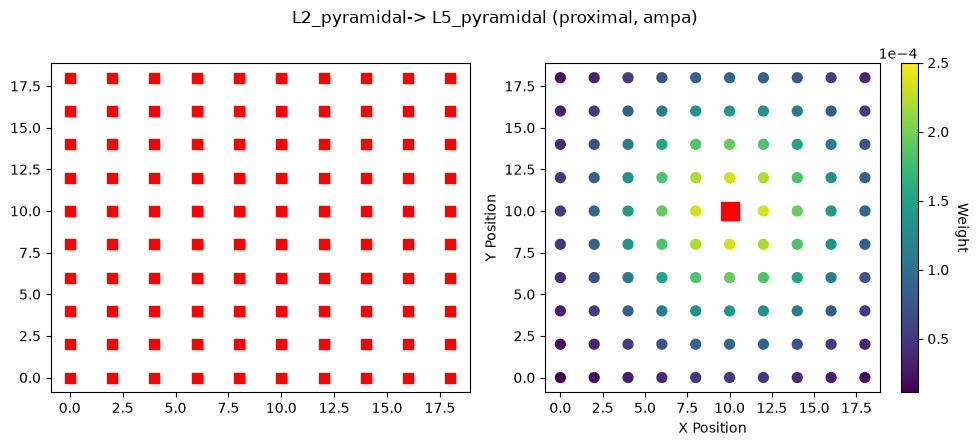

In [15]:
idx = pick_connection(
    net, src_gids="L2_pyramidal", target_gids="L5_pyramidal", loc="proximal"
)[0]
src_gid = net.gid_ranges["L2_pyramidal"][55]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_cell_connectivity(net, idx, src_gid=src_gid, axes=axes, show=False)
plt.show()

To quickly scale many connections at once, [`Network.set_global_synaptic_gains()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.set_global_synaptic_gains) sets the `gain` of every
connection between cells, grouped by whether the source and target are excitatory
(pyramidal) or inhibitory (basket): `e_e`, `e_i`, `i_e` and `i_i`. It does not change
drive connections.

In [16]:
net.set_global_synaptic_gains(e_e=1.0, e_i=1.2, i_e=0.9, i_i=1.0)

show("net.get_global_synaptic_gains()")

net.get_global_synaptic_gains()  ->  {'e_e': 1.0, 'e_i': 1.2, 'i_e': 0.9, 'i_i': 1.0}


### Parameters fixed when a connection is created

When a connection is created, HNN-Core works out which source cells connect to which
target cells, once, and stores the result in the connection's `gid_pairs` (at `Network.connectivity[<connection idx>]['gid_pairs']`). The arguments
of
[`Network.add_connection()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.add_connection)
that go into that calculation can only be set at that point:

| Argument | Meaning |
| --- | --- |
| `src_gids`, `target_gids` | the source and target cells: a cell type name, or one or more cell IDs |
| `loc` | where on the target cells the synapses are placed: `"proximal"`, `"distal"`, `"soma"`, or the name of a single section |
| `receptor` | `"ampa"`, `"nmda"`, `"gabaa"` or `"gabab"` |
| `probability` | the chance that each possible pair of source and target cells is connected (default `1.0`, all-to-all) |
| `conn_seed` | random seed that decides which pairs are kept when `probability` is below 1 |
| `allow_autapses` | whether a cell may connect to itself, when the source and target are the same cell type |

The connection keeps a record of these values, but you should *not* edit them after creation, since certain variables will not be recalculated after creation. `add_connection()` also takes `weight`, `delay`, `lamtha`, `threshold` and `gain`, which
set the starting values of the `nc_dict` parameters described in the previous sub-section.

> **Note:** Currently, the only way to re-add a connection is to use
> [`Network.clear_connectivity()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.clear_connectivity)
> to first delete **all** recurrent connections (connections from drives are kept), and
> then rebuild all of your connections with `add_connection()`.

The cell below does this for `net_sparse`, a copy of `net`. It keeps a reference to the
old list of connections, clears the connectivity, and adds every connection back with the
same values, except that the L5 pyramidal → L5 pyramidal connections now connect only 10%
of the possible cell pairs. The rest of this page continues with `net`, whose connections
are unchanged.

In [17]:
net_sparse = net.copy()

old_connectivity = net_sparse.connectivity
net_sparse.clear_connectivity()

for conn in old_connectivity:
    if conn["src_type"] in net_sparse.external_drives:
        continue  # connections from drives were kept by clear_connectivity()

    probability = conn["probability"]
    if conn["src_type"] == conn["target_type"] == "L5_pyramidal":
        probability = 0.1

    net_sparse.add_connection(
        src_gids=conn["src_type"],
        target_gids=conn["target_type"],
        loc=conn["loc"],
        receptor=conn["receptor"],
        weight=conn["nc_dict"]["A_weight"],
        delay=conn["nc_dict"]["A_delay"],
        lamtha=conn["nc_dict"]["lamtha"],
        threshold=conn["nc_dict"]["threshold"],
        gain=conn["nc_dict"]["gain"],
        allow_autapses=conn["allow_autapses"],
        probability=probability,
        conn_seed=3,
    )

show("len(net.connectivity)", "len(net_sparse.connectivity)")

len(net.connectivity)         ->  16
len(net_sparse.connectivity)  ->  16


`Network.connectivity[<connection idx>]['gid_pairs']` maps each source cell to the target cells it connects to, so counting its
entries gives the number of connected cell pairs.
[`plot_connectivity_matrix()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.viz.plot_connectivity_matrix.html#hnn_core.viz.plot_connectivity_matrix)
draws the same thing as a matrix of source cells by target cells, shaded by the weight of
each connected pair. Note that the sparsity is in addition to the falloff of weight with
distance.

---------------
Initial values:
---------------
net.connectivity[idx_all]['probability']                                          ->  1.0
sum(len(targets) for targets in net.connectivity[idx_all]['gid_pairs'].values())  ->  9900
---------------
 After change:
---------------
net_sparse.connectivity[idx_sparse]['probability']                                          ->  0.1
sum(len(targets) for targets in net_sparse.connectivity[idx_sparse]['gid_pairs'].values())  ->  990


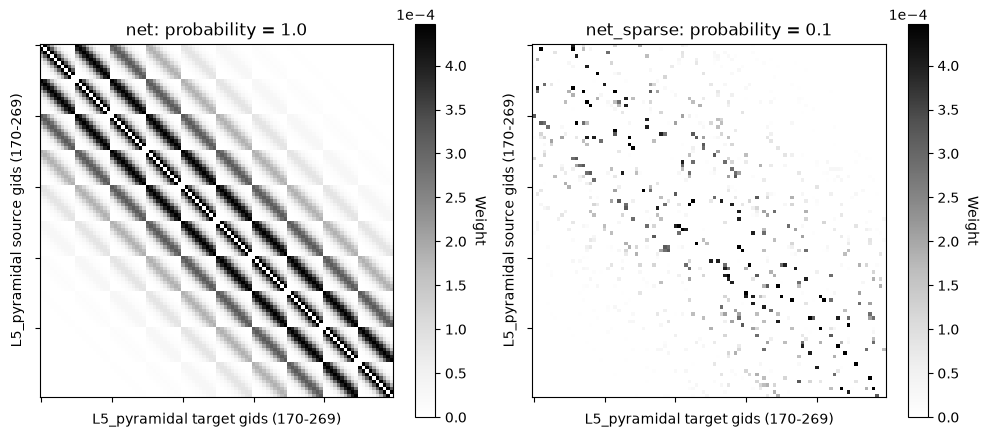

In [18]:
idx_all = pick_connection(
    net, src_gids="L5_pyramidal", target_gids="L5_pyramidal", receptor="ampa"
)[0]
idx_sparse = pick_connection(
    net_sparse, src_gids="L5_pyramidal", target_gids="L5_pyramidal", receptor="ampa"
)[0]

print("---------------\nInitial values:\n---------------")
show(
    "net.connectivity[idx_all]['probability']",
    "sum(len(targets) for targets in net.connectivity[idx_all]['gid_pairs'].values())",
)

print("---------------\n After change:\n---------------")
show(
    "net_sparse.connectivity[idx_sparse]['probability']",
    "sum(len(targets) for targets in net_sparse.connectivity[idx_sparse]['gid_pairs'].values())",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_connectivity_matrix(net, idx_all, ax=axes[0], show=False)
plot_connectivity_matrix(net_sparse, idx_sparse, ax=axes[1], show=False)
axes[0].set_title("net: probability = 1.0")
axes[1].set_title("net_sparse: probability = 0.1")
plt.show()

## 5. External Drives

Drives are the network's external inputs: populations of artificial "drive cells" that
send spikes into the network through ordinary connections. There are four kinds:

- an **evoked** drive, in which each drive cell fires a few spikes at times drawn from a
  Gaussian distribution, like the thalamic input that follows a sensory stimulus;
- a **rhythmic** drive, which fires bursts of spikes at a regular rate;
- a **Poisson** drive, which fires spikes at random times, at a constant average rate;
- a **spike train** drive, which replays spike times that you provide, such as spikes
  recorded in an experiment or simulated by another network.

We add one each of the first three kinds to `net` below. Spike train drives differ from
the others in a few ways, so we cover them separately at the end of this section.

Each kind of drive has its own timing parameters:

| Drive | `Network` Method | Timing parameters |
| --- | --- | --- |
| evoked | [`add_evoked_drive()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.add_evoked_drive) | `mu`, `sigma`: mean and standard deviation of the spike times (ms); `numspikes`: spikes per drive cell |
| rhythmic | [`add_bursty_drive()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.add_bursty_drive) | `tstart`, `tstop`: when the bursts begin and end (ms; `tstop=None` means the end of the simulation); `tstart_std`: jitter of `tstart` (ms); `burst_rate`: bursts per second (Hz); `burst_std`: jitter of each burst's timing (ms); `numspikes`: spikes per burst; `spike_isi`: interval between the spikes of a burst (ms) |
| Poisson | [`add_poisson_drive()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.add_poisson_drive) | `tstart`, `tstop` (ms), as above; `rate_constant`: mean spike rate (Hz), either one value or one per target cell type |
| spike train | [`add_spike_train_drive()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.add_spike_train_drive) | `spike_data`: the spike times (ms) of each drive cell, which are replayed unchanged in every trial |

and all of them share these connection parameters, except where noted:

| Parameter | Meaning |
| --- | --- |
| `location` | where the drive's synapses are placed: `"proximal"` or `"distal"` (the groups of sections listed in each template's `sect_loc`), or the name of a single section such as `"soma"`. (L5 basket cells have no distal sections, so a distal drive cannot target them.) |
| `weights_ampa`, `weights_nmda` | peak synaptic conductance (µS) onto each target cell type. A cell type missing from both is not targeted. |
| `synaptic_delays` | delay (ms) onto each target cell type, or a single value for all of them |
| `space_constant` | becomes the `lamtha` of the drive's connections (Section 4) |
| `probability`, `conn_seed` | for connections onto cells (Section 4) |
| `n_drive_cells`, `cell_specific` | how many drive cells there are, and how they connect. With `cell_specific=True` and `n_drive_cells="n_cells"` (the default for evoked and Poisson drives), each target cell gets its own drive cell with independently drawn spike times. With `cell_specific=False`, each of the `n_drive_cells` drive cells connects to every target cell, so all targets receive the same spikes (the default for rhythmic drives, with a single drive cell). Spike train drives take neither: they have one drive cell for each source in `spike_data`, and each drive cell connects to every target cell. |
| `event_seed` | random seed for the spike times. It is combined with the trial number, so that each trial differs. Spike train drives take no `event_seed`, since their spike times are not random. |

In [19]:
# Evoked drive onto proximal dendrites
net.add_evoked_drive(
    "evprox1",
    mu=26.61,
    sigma=2.47,
    numspikes=1,
    location="proximal",
    n_drive_cells="n_cells",
    cell_specific=True,
    weights_ampa={
        "L2_basket": 0.08831,
        "L2_pyramidal": 0.01525,
        "L5_basket": 0.19934,
        "L5_pyramidal": 0.00865,
    },
    synaptic_delays={
        "L2_basket": 0.1,
        "L2_pyramidal": 0.1,
        "L5_basket": 1.0,
        "L5_pyramidal": 1.0,
    },
    space_constant=3.0,
    probability=1.0,
    event_seed=274,
    conn_seed=3,
)

# Rhythmic drive onto distal dendrites, bursting at 10 Hz (alpha)
net.add_bursty_drive(
    "alpha_dist",
    tstart=50.0,
    tstart_std=0.0,
    tstop=None,
    burst_rate=10.0,
    burst_std=20.0,
    numspikes=2,
    spike_isi=10.0,
    location="distal",
    n_drive_cells=10,
    cell_specific=False,
    weights_ampa={"L2_pyramidal": 5.4e-5, "L5_pyramidal": 5.4e-5},
    synaptic_delays=0.1,
    event_seed=278,
)

# Poisson drive onto proximal dendrites
net.add_poisson_drive(
    "poisson_prox",
    tstart=0.0,
    tstop=None,
    rate_constant={"L2_pyramidal": 10.0, "L5_pyramidal": 10.0},
    location="proximal",
    weights_ampa={"L2_pyramidal": 5e-4, "L5_pyramidal": 5e-4},
    synaptic_delays={"L2_pyramidal": 0.1, "L5_pyramidal": 1.0},
    event_seed=1079,
)

show("list(net.external_drives)", "len(net.connectivity)")

list(net.external_drives)  ->  ['evprox1', 'alpha_dist', 'poisson_prox']
len(net.connectivity)      ->  24


### Changing a drive's timing and dynamics

A drive's timing and stimulus-related parameters are stored in `net.external_drives[<drive name>]["dynamics"]`. `event_seed` is stored at the same level, at `net.external_drives[<drive name>]["event_seed"]`. The ultimate resulting spike times are generated from these values each time you simulate, so these parameters can be changed in-place anytime before you run a simulation.

In [20]:
print("---------------\nInitial values:\n---------------")
show(
    "net.external_drives['evprox1']['dynamics']",
    "net.external_drives['alpha_dist']['dynamics']",
    "net.external_drives['poisson_prox']['dynamics']",
)

net.external_drives["evprox1"]["dynamics"]["mu"] = 30.0
net.external_drives["evprox1"]["event_seed"] = 275
net.external_drives["alpha_dist"]["dynamics"]["burst_rate"] = 12.0
net.external_drives["poisson_prox"]["dynamics"]["rate_constant"]["L5_pyramidal"] = 15.0

print("---------------\n After change:\n---------------")
show(
    "net.external_drives['evprox1']['dynamics']",
    "net.external_drives['evprox1']['event_seed']",
    "net.external_drives['alpha_dist']['dynamics']",
    "net.external_drives['poisson_prox']['dynamics']",
)

---------------
Initial values:
---------------
net.external_drives['evprox1']['dynamics']       ->  {'mu': 26.61, 'sigma': 2.47, 'numspikes': 1}
net.external_drives['alpha_dist']['dynamics']    ->  {'tstart': 50.0, 'tstart_std': 0.0, 'tstop': None, 'burst_rate': 10.0, 'burst_std': 20.0, 'numspikes': 2, 'spike_isi': 10.0}
net.external_drives['poisson_prox']['dynamics']  ->  {'tstart': 0.0, 'tstop': None, 'rate_constant': {'L2_pyramidal': 10.0, 'L5_pyramidal': 10.0}}
---------------
 After change:
---------------
net.external_drives['evprox1']['dynamics']       ->  {'mu': 30.0, 'sigma': 2.47, 'numspikes': 1}
net.external_drives['evprox1']['event_seed']     ->  275
net.external_drives['alpha_dist']['dynamics']    ->  {'tstart': 50.0, 'tstart_std': 0.0, 'tstop': None, 'burst_rate': 12.0, 'burst_std': 20.0, 'numspikes': 2, 'spike_isi': 10.0}
net.external_drives['poisson_prox']['dynamics']  ->  {'tstart': 0.0, 'tstop': None, 'rate_constant': {'L2_pyramidal': 10.0, 'L5_pyramidal': 15.0}}


### Changing a drive's connections

A drive's connections are ordinary entries in `net.connectivity`, so you change their
weights, delays and space constants exactly as in Section 4, passing the drive's name to
`pick_connection()`.

`net.external_drives[<drive name>]` also contains `weights_ampa`, `weights_nmda` and
`synaptic_delays` entries, but these are only a record of the arguments the drive was
created with. Changing them has no effect: the values used in the simulation are the ones
in `net.connectivity`.

In [21]:
indices = pick_connection(net, src_gids="alpha_dist", target_gids="L5_pyramidal")
for idx in indices:
    net.connectivity[idx]["nc_dict"]["A_weight"] = 6e-5

show("net.connectivity[indices[0]]['nc_dict']")

net.connectivity[indices[0]]['nc_dict']  ->  {'A_delay': 0.1, 'A_weight': 6e-05, 'lamtha': 100.0, 'threshold': -10.0, 'gain': 1.0}


### Parameters fixed when a drive is added

As with the connections in Section 4, some drive parameters decide which drive cells and
connections exist, so they can only be set when the drive is added: `location`,
`n_drive_cells`, `cell_specific`, `probability`, `conn_seed`, and which cell types and
receptors the drive targets at all. For example, `evprox1` has no NMDA connections whose
weight you could raise, because we did not give it any `weights_nmda`.

To change any of these, call `net.clear_drives()`, which removes every drive along with
its connections, and then add the drives again with the new values.

### Spike train drives

[`Network.add_spike_train_drive()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.add_spike_train_drive)
takes the spike times themselves, as `spike_data`, in one of two forms:

- a dictionary that maps a name for each source (any string) to a list of its spike
  times; or
- a list of `(spike time, source ID)` tuples, where the source IDs can be any integers.

(It also accepts the path of spike files saved with `CellResponse.write()`, but reading
those files is deprecated.)

Each source becomes one drive cell. List each source's spike times in increasing order:
if they go backwards, NEURON aborts the simulation and takes your Python session down
with it.

We add the drive to `net_replay`, a copy of `net`, rather than to `net` itself. In the
current version of HNN-Core, `read_network_configuration()` cannot load a network that
contains a spike train drive, so adding one to `net` would break Section 9. See
[7.12 Replaying Spike Data as Input](https://jonescompneurolab.github.io/textbook/content/08_using_hnn_api/replaying_spike_data_as_input.html)
for a full example that replays the spikes of one simulated network into another.

In [22]:
net_replay = net.copy()

net_replay.add_spike_train_drive(
    "replay",
    spike_data={
        "source_a": [40.0, 60.0],
        "source_b": [45.0],
        "source_c": [50.0, 70.0, 90.0],
    },
    location="distal",
    weights_ampa={"L2_pyramidal": 0.001, "L5_pyramidal": 0.001},
    synaptic_delays=0.1,
)

show(
    "list(net_replay.external_drives)",
    "net_replay.external_drives['replay']['n_drive_cells']",
)

list(net_replay.external_drives)                       ->  ['evprox1', 'alpha_dist', 'poisson_prox', 'replay']
net_replay.external_drives['replay']['n_drive_cells']  ->  3


/Users/austinsoplata/rep/brn/hnn-core/hnn_core/network.py:1444: UserWarning: Spike train drives can only target sections defined in `Cell.sect_loc` when `legacy_mode=False`.
  warnings.warn(


`net_replay.external_drives["replay"]["dynamics"]` stores every spike time in a single
list, `"times"`, and the drive cell (`0` to `n_drive_cells - 1`) that fires each spike in
a second list, `"gids"`. When `spike_data` is a dictionary, `"source_to_gid_map"`
records which source became which drive cell.

As with the other drives, spike times are read from `"dynamics"` each time you simulate,
so you can change them in place. The drive's connections are entries in
`net_replay.connectivity`, which you change exactly as for any other drive.

In [23]:
print("---------------\nInitial values:\n---------------")
show(
    "net_replay.external_drives['replay']['dynamics']",
    "net_replay.external_drives['replay']['source_to_gid_map']",
)

# Delay every replayed spike by 10 ms
dynamics = net_replay.external_drives["replay"]["dynamics"]
dynamics["times"] = [time + 10.0 for time in dynamics["times"]]

indices = pick_connection(net_replay, src_gids="replay", target_gids="L5_pyramidal")
for idx in indices:
    net_replay.connectivity[idx]["nc_dict"]["A_weight"] = 0.002

print("---------------\n After change:\n---------------")
show(
    "net_replay.external_drives['replay']['dynamics']",
    "net_replay.connectivity[indices[0]]['nc_dict']",
)

---------------
Initial values:
---------------
net_replay.external_drives['replay']['dynamics']           ->  {'times': [40.0, 60.0, 45.0, 50.0, 70.0, 90.0], 'gids': [0, 0, 1, 2, 2, 2]}
net_replay.external_drives['replay']['source_to_gid_map']  ->  {'source_a': 0, 'source_b': 1, 'source_c': 2}
---------------
 After change:
---------------
net_replay.external_drives['replay']['dynamics']  ->  {'times': [50.0, 70.0, 55.0, 60.0, 80.0, 100.0], 'gids': [0, 0, 1, 2, 2, 2]}
net_replay.connectivity[indices[0]]['nc_dict']    ->  {'A_delay': 0.1, 'A_weight': 0.002, 'lamtha': 3.0, 'threshold': -10.0, 'gain': 1.0}


Which sources the drive replays is fixed when it is added, along with the parameters
in the previous sub-section, because each source is a drive cell with its own
connections. To replay a different set of sources, call `clear_drives()` and add the
drives again.

## 6. Tonic inputs

[`Network.add_tonic_bias()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.add_tonic_bias) injects a constant current into cells: `amplitude` (nA) for each
target cell type, into the section named by `section` (the soma by default), from `t0`
to `tstop` (ms; `tstop=None` means the end of the simulation). These values are stored
in `net.external_biases[<bias name>][<cell type>]` and read when the network is built, so
they can also be changed in place.

In [24]:
net.add_tonic_bias(amplitude={"L5_pyramidal": 0.01}, section="soma", t0=0.0, tstop=None)

print("---------------\nInitial values:\n---------------")
show("net.external_biases['tonic']['L5_pyramidal']['amplitude']")

net.external_biases["tonic"]["L5_pyramidal"]["amplitude"] = 0.02

print("---------------\n After change:\n---------------")
show("net.external_biases['tonic']['L5_pyramidal']['amplitude']")

---------------
Initial values:
---------------
net.external_biases['tonic']['L5_pyramidal']['amplitude']  ->  0.01
---------------
 After change:
---------------
net.external_biases['tonic']['L5_pyramidal']['amplitude']  ->  0.02


## 7. Running the simulation

`net` now carries every change made on this page, and [`simulate_dipole()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.simulate_dipole.html#hnn_core.simulate_dipole) runs it like
any other network. The settings for the simulation itself are not stored on the network.
Instead, you pass them to `simulate_dipole()` as arguments each time you run it:

| Argument | Meaning | Default |
| --- | --- | --- |
| `tstop` | length of the simulation (ms) | none, required |
| `dt` | integration time step (ms) | `0.025` |
| `n_trials` | number of trials; each trial draws new drive spike times (Section 5) | `1` |
| `record_vsec` | record membrane voltage from the soma (`"soma"`), from all sections (`"all"`), or not at all (`False`) | `False` |
| `record_isec` | record synaptic currents, with the same options | `False` |
| `record_ca` | record calcium concentration, with the same options | `False` |

In [25]:
dpls = simulate_dipole(net, tstop=170.0, dt=0.025, n_trials=1)

Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Loading custom mechanism files from /Users/austinsoplata/rep/brn/hnn-core/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...


## 8. Processing the dipole

`simulate_dipole()` returns a list with one `Dipole` per trial. A simulated dipole
usually goes through two processing steps before it is compared with
data. Both are methods of the `Dipole` object, not parameters of the network:

- [`Dipole.smooth(window_len)`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.dipole.Dipole.html#hnn_core.dipole.Dipole.smooth) smooths it with a Hamming window `window_len` ms wide;
- [`Dipole.scale(factor)`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.dipole.Dipole.html#hnn_core.dipole.Dipole.scale) multiplies it by `factor`. The model network is far smaller than the
  patch of cortex that produces a measured signal, and this factor accounts for the
  difference.

Both change the dipole in place and return it, so they can be chained. We apply them to a
copy, so that the raw dipole is kept.

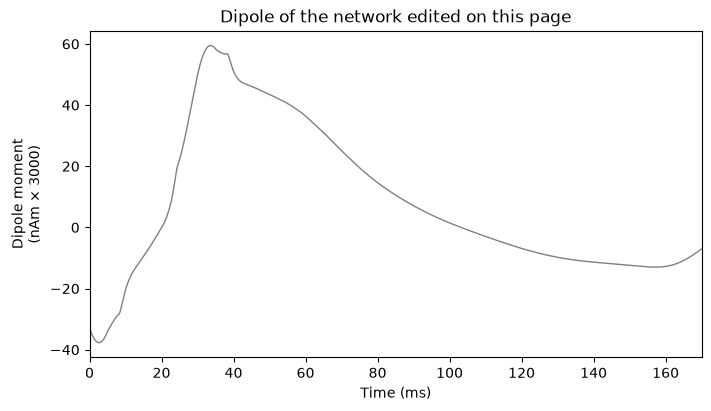

In [26]:
dpl = dpls[0].copy().smooth(window_len=30.0).scale(3000)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
dpl.plot(ax=ax, show=False)
ax.set_title("Dipole of the network edited on this page")
plt.show()

## 9. Saving and reloading

[`net.write_configuration()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.Network.html#hnn_core.Network.write_configuration) saves every parameter stored on the network to a JSON file:
the cell templates, all connections, the drives and tonic inputs, and the temperature and
spike threshold. [`read_network_configuration()`](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.hnn_io.read_network_configuration.html#hnn_core.hnn_io.read_network_configuration) creates the network again from that file,
so you can pick up where you left off or share your model with others. The simulation
settings from Section 7 and the processing steps from Section 8 are not part of the
network, so keep your own record of those.

In [27]:
config_path = Path(tempfile.mkdtemp()) / "my_network.json"
net.write_configuration(config_path)

net_reloaded = read_network_configuration(config_path)

idx = pick_connection(net_reloaded, src_gids="alpha_dist", target_gids="L5_pyramidal")[0]
show(
    "net_reloaded._params['celsius']",
    "net_reloaded.threshold",
    "net_reloaded.cell_types['L5_pyramidal']['cell_object'].synapses['gabab']",
    "net_reloaded.external_drives['evprox1']['dynamics']",
    "net_reloaded.connectivity[idx]['nc_dict']['A_weight']",
)

net_reloaded._params['celsius']                                           ->  36.0
net_reloaded.threshold                                                    ->  -10.0
net_reloaded.cell_types['L5_pyramidal']['cell_object'].synapses['gabab']  ->  {'e': -80.0, 'tau1': 45.0, 'tau2': 200.0, 'mechname': 'Exp2Syn'}
net_reloaded.external_drives['evprox1']['dynamics']                       ->  {'mu': 30.0, 'sigma': 2.47, 'numspikes': 1}
net_reloaded.connectivity[idx]['nc_dict']['A_weight']                     ->  6e-05
